<a href="https://colab.research.google.com/github/Amruth-U-tech/Multi-Model-AI/blob/main/Colab-runs/text_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =============================================================================
# CELL 1 — Title & Project Info
# =============================================================================
# %% [markdown]
"""
# 📝 Multi-Modal AI — Text Analysis Pipeline
## Dataset Quality, Preprocessing Validation & Semantic Signal Estimation

**Pipeline Overview:**
- Load preprocessed CSV datasets (with text column)
- Validate required columns and dataset structure
- Clean and tokenize text per row
- Safely extract per-text linguistic statistics
- Generate visual distributions and random sample previews
- Print final insight summary for NLP / multimodal model readiness

**Goal:** Understand semantic structure and language quality BEFORE training.
"""

# =============================================================================
# CELL 2 — Install & Import Dependencies
# =============================================================================
# %%
# ── Uncomment if running on fresh Colab ──────────────────────────────────────
# !pip install pandas numpy matplotlib scikit-learn nltk tqdm --quiet

In [1]:
!pip install pandas numpy matplotlib scikit-learn nltk tqdm --quiet

In [2]:
import os
import re
import warnings
import random
import traceback
from collections import Counter
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# ── NLTK resource downloads ───────────────────────────────────────────────────
nltk.download("punkt",         quiet=True)
nltk.download("punkt_tab",     quiet=True)
nltk.download("stopwords",     quiet=True)

warnings.filterwarnings("ignore")

STOP_WORDS = set(stopwords.words("english"))

print("✅ All libraries imported successfully.")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   matplotlib : {plt.matplotlib.__version__}")
print(f"   nltk       : {nltk.__version__}")


✅ All libraries imported successfully.
   pandas     : 2.2.2
   numpy      : 2.0.2
   matplotlib : 3.10.0
   nltk       : 3.9.1


# =============================================================================
# CELL 3 — Configuration (Single Source of Truth — Edit Only Here)
# =============================================================================
# %%

In [3]:
 #── List of preprocessed CSV dataset paths ───────────────────────────────────
CSV_FILES = [
    "/content/drive/MyDrive/preprocessed-datasets/sample_100.csv"
]

# ── Name of the column containing raw text ───────────────────────────────────
TEXT_COLUMN = "text"          # ← change this if your column differs

# ── Max random text samples to display for manual inspection ─────────────────
MAX_SAMPLE_DISPLAY = 10

# ── Reproducibility seed ─────────────────────────────────────────────────────
RANDOM_SEED = 42

print("✅ Configuration loaded.")
print(f"   CSV files        : {len(CSV_FILES)}")
print(f"   Text column      : {TEXT_COLUMN}")
print(f"   Max sample display: {MAX_SAMPLE_DISPLAY}")


✅ Configuration loaded.
   CSV files        : 1
   Text column      : text
   Max sample display: 10


# =============================================================================
# CELL 4 — Validation Helpers
# =============================================================================
# %%

In [4]:
def validate_dataset_inputs(csv_path: str, text_column: str) -> bool:
    """
    Validates all required inputs before processing a dataset.

    Checks:
      1. CSV file exists on disk
      2. text_column is present in CSV
      3. text_column has at least some non-null values

    Args:
        csv_path    : Absolute path to the CSV dataset file.
        text_column : Name of the column containing raw text.

    Returns:
        True if all checks pass, False otherwise (caller should skip).
    """
    dataset_name = os.path.basename(csv_path)

    # ── Check 1: CSV file exists ──────────────────────────────────────────────
    if not os.path.exists(csv_path):
        print(f"   ❌ [SKIP] CSV file not found: {csv_path}")
        return False

    # ── Check 2: text_column present ─────────────────────────────────────────
    try:
        df_peek = pd.read_csv(csv_path, nrows=1)
    except Exception as e:
        print(f"   ❌ [SKIP] Cannot read CSV '{dataset_name}': {e}")
        return False

    if text_column not in df_peek.columns:
        print(f"   ❌ [SKIP] '{text_column}' column missing in '{dataset_name}'.")
        print(f"      Available columns: {list(df_peek.columns)}")
        return False

    # ── Check 3: column has non-null data ─────────────────────────────────────
    df_check = pd.read_csv(csv_path, usecols=[text_column])
    if df_check[text_column].notna().sum() == 0:
        print(f"   ❌ [SKIP] '{text_column}' column is entirely null in '{dataset_name}'.")
        return False

    return True


print("✅ validate_dataset_inputs() defined.")


✅ validate_dataset_inputs() defined.


# =============================================================================
# CELL 5 — Core Text Analysis Function
# =============================================================================
# %%

In [5]:
def analyze_text(text: str) -> Optional[Dict]:
    """
    Safely cleans and tokenizes a single text entry, then extracts
    linguistic and statistical features.

    Extracted metrics:
      - character_count        : Total characters (raw)
      - word_count             : Total word tokens after cleaning
      - sentence_count         : Approximate sentence count via regex split
      - unique_word_count      : Distinct lowercase word types
      - lexical_diversity      : unique_word_count / word_count  (TTR)
      - stopword_ratio         : Fraction of tokens that are stopwords
      - special_character_ratio: Fraction of chars that are non-alphanumeric/space

    Edge cases handled:
      - None / NaN input
      - Empty string after stripping
      - Special-character-only text (no alphabetic tokens)
      - Tokenization failure

    Args:
        text : Raw text string from a dataset row.

    Returns:
        Dict of stats on success, None on any failure.
    """
    # ── Guard: None or NaN ────────────────────────────────────────────────────
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return None

    text = str(text).strip()

    # ── Guard: empty after strip ──────────────────────────────────────────────
    if not text:
        return None

    char_count = len(text)

    # ── Special character ratio (before tokenization) ─────────────────────────
    special_chars         = re.sub(r"[a-zA-Z0-9\s]", "", text)
    special_char_ratio    = round(len(special_chars) / char_count, 4) if char_count > 0 else 0.0

    # ── Sentence count (split on . ! ?) ───────────────────────────────────────
    sentences      = re.split(r"[.!?]+", text)
    sentence_count = max(1, len([s for s in sentences if s.strip()]))

    # ── Tokenize ──────────────────────────────────────────────────────────────
    try:
        tokens = word_tokenize(text.lower())
    except Exception:
        return None

    # ── Filter to alphabetic tokens only ──────────────────────────────────────
    word_tokens = [t for t in tokens if t.isalpha()]

    # ── Guard: no alphabetic tokens (e.g. emoji-only / symbol-only text) ──────
    if not word_tokens:
        return None

    word_count        = len(word_tokens)
    unique_words      = set(word_tokens)
    unique_word_count = len(unique_words)

    # ── Lexical diversity (Type-Token Ratio) ──────────────────────────────────
    lexical_diversity = round(unique_word_count / word_count, 4) if word_count > 0 else 0.0

    # ── Stopword ratio ────────────────────────────────────────────────────────
    stop_tokens   = [t for t in word_tokens if t in STOP_WORDS]
    stopword_ratio = round(len(stop_tokens) / word_count, 4) if word_count > 0 else 0.0

    return {
        "character_count"        : char_count,
        "word_count"             : word_count,
        "sentence_count"         : sentence_count,
        "unique_word_count"      : unique_word_count,
        "lexical_diversity"      : lexical_diversity,
        "stopword_ratio"         : stopword_ratio,
        "special_character_ratio": special_char_ratio,
        "cleaned_text"           : " ".join(word_tokens),   # for TF-IDF / vocab
    }


print("✅ analyze_text() defined.")

✅ analyze_text() defined.


# =============================================================================
# CELL 6 — Dataset-Level Statistics Extractor
# =============================================================================
# %%

In [6]:
def extract_dataset_stats(
    df: pd.DataFrame,
    text_column: str,
    dataset_name: str,
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Iterates through the dataset, runs analyze_text() on each row,
    and collects results into a stats DataFrame.

    Args:
        df           : Loaded dataset DataFrame with text_column.
        text_column  : Name of the text column to analyze.
        dataset_name : Human-readable label for tqdm progress bar.

    Returns:
        stats_df    : DataFrame of per-text statistics (successful rows only).
        failed_list : List of raw texts that failed to analyze.
    """
    stats_rows  = []
    failed_list = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Analyzing {dataset_name}"):

        raw_text = row.get(text_column, None)

        # ── Guard: missing text value ─────────────────────────────────────────
        if pd.isna(raw_text) or not str(raw_text).strip():
            failed_list.append(str(raw_text)[:80])
            continue

        stats = analyze_text(raw_text)

        if stats is None:
            failed_list.append(str(raw_text)[:80])
            continue

        # ── Attach raw text for display purposes ──────────────────────────────
        stats["raw_text"] = str(raw_text)
        stats_rows.append(stats)

    stats_df = pd.DataFrame(stats_rows) if stats_rows else pd.DataFrame()
    return stats_df, failed_list


print("✅ extract_dataset_stats() defined.")

✅ extract_dataset_stats() defined.


# =============================================================================
# CELL 7 — Visualization Functions
# =============================================================================
# %%

In [7]:
def plot_distributions(stats_df: pd.DataFrame, dataset_name: str) -> None:
    """
    Generates a 5-panel distribution plot for key text statistics:
      - Word count distribution
      - Lexical diversity distribution
      - Stopword ratio distribution
      - Special character ratio distribution
      - Sentence count distribution

    Args:
        stats_df     : DataFrame of per-text statistics.
        dataset_name : Used as the figure title.
    """
    if stats_df.empty:
        print("   ⚠️  No stats available — skipping distribution plots.")
        return

    metrics = [
        ("word_count",              "Word Count",                    "#4C72B0"),
        ("lexical_diversity",       "Lexical Diversity (TTR)",       "#DD8452"),
        ("stopword_ratio",          "Stopword Ratio",                "#55A868"),
        ("special_character_ratio", "Special Character Ratio",       "#C44E52"),
        ("sentence_count",          "Sentence Count",                "#8172B2"),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(26, 4))
    fig.suptitle(
        f"📊 Text Distribution Analysis — {dataset_name}",
        fontsize=14, fontweight="bold", y=1.02
    )

    for ax, (col, label, color) in zip(axes, metrics):
        if col not in stats_df.columns:
            ax.set_visible(False)
            continue

        data = stats_df[col].dropna()
        ax.hist(data, bins=30, color=color, edgecolor="white", alpha=0.85)
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2,
                   label=f"Mean: {data.mean():.2f}")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"   ✅ Distribution plots rendered for '{dataset_name}'.")


def plot_top_words(stats_df: pd.DataFrame, dataset_name: str, top_n: int = 30) -> None:
    """
    Computes and plots the top N most frequent non-stopword tokens
    across all cleaned texts in the dataset.

    Args:
        stats_df     : DataFrame containing 'cleaned_text' column.
        dataset_name : Used as the figure title.
        top_n        : Number of top words to display.
    """
    if stats_df.empty or "cleaned_text" not in stats_df.columns:
        print("   ⚠️  No cleaned text available — skipping top words plot.")
        return

    all_tokens = []
    for text in stats_df["cleaned_text"].dropna():
        tokens = text.split()
        all_tokens.extend([t for t in tokens if t not in STOP_WORDS and len(t) > 2])

    if not all_tokens:
        print("   ⚠️  No content tokens found after stopword removal.")
        return

    top_words  = Counter(all_tokens).most_common(top_n)
    words, counts = zip(*top_words)

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(words)), counts, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha="right", fontsize=9)
    ax.set_title(
        f"🔤 Top {top_n} Most Frequent Content Words — {dataset_name}",
        fontsize=13, fontweight="bold"
    )
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"   ✅ Top words plot rendered for '{dataset_name}'.")


def display_text_samples(
    stats_df: pd.DataFrame,
    dataset_name: str,
    max_samples: int = 10,
    seed: int = 42,
) -> None:
    """
    Prints a random selection of raw texts for manual semantic inspection.

    Args:
        stats_df     : DataFrame containing 'raw_text' column.
        dataset_name : Used as section header.
        max_samples  : Maximum number of texts to display.
        seed         : Random seed for reproducible sampling.
    """
    if stats_df.empty or "raw_text" not in stats_df.columns:
        print("   ⚠️  No raw text available — skipping sample display.")
        return

    texts = stats_df["raw_text"].dropna().tolist()
    if not texts:
        print("   ⚠️  No valid texts found — skipping sample display.")
        return

    random.seed(seed)
    samples = random.sample(texts, min(max_samples, len(texts)))

    print(f"\n{'='*65}")
    print(f"  🔎  RANDOM TEXT SAMPLES — {dataset_name}  (n={len(samples)})")
    print(f"{'='*65}")
    for i, t in enumerate(samples, 1):
        display = t[:300] + ("..." if len(t) > 300 else "")
        print(f"\n  [{i:02d}] {display}")
    print(f"\n{'='*65}")
    print(f"   ✅ Sample display complete.")


print("✅ plot_distributions(), plot_top_words(), display_text_samples() defined.")


✅ plot_distributions(), plot_top_words(), display_text_samples() defined.


# =============================================================================
# CELL 8 — TF-IDF Keyword Importance Estimator
# =============================================================================
# %%


In [8]:
def run_tfidf_analysis(stats_df: pd.DataFrame, dataset_name: str, top_n: int = 20) -> None:
    """
    Runs TF-IDF across all cleaned texts to estimate keyword importance
    at the corpus level. Displays top N highest mean-TF-IDF terms.

    Args:
        stats_df     : DataFrame containing 'cleaned_text' column.
        dataset_name : Used for display.
        top_n        : Number of top TF-IDF terms to display.
    """
    if stats_df.empty or "cleaned_text" not in stats_df.columns:
        print("   ⚠️  No cleaned text available — skipping TF-IDF analysis.")
        return

    corpus = stats_df["cleaned_text"].dropna().tolist()
    if len(corpus) < 2:
        print("   ⚠️  Need at least 2 documents for TF-IDF — skipping.")
        return

    try:
        vectorizer = TfidfVectorizer(
            max_features=500,
            stop_words="english",
            min_df=2,
            ngram_range=(1, 2),
        )
        tfidf_matrix  = vectorizer.fit_transform(corpus)
        feature_names = vectorizer.get_feature_names_out()
        mean_scores   = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
        top_indices   = mean_scores.argsort()[::-1][:top_n]
        top_terms     = [(feature_names[i], round(mean_scores[i], 5)) for i in top_indices]

        print(f"\n  📌 Top {top_n} TF-IDF Terms (corpus-level mean) — {dataset_name}:")
        for rank, (term, score) in enumerate(top_terms, 1):
            print(f"     {rank:>3}. {term:<30} score={score:.5f}")

        # ── Bar chart ────────────────────────────────────────────────────────
        terms, scores = zip(*top_terms)
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.bar(range(len(terms)), scores, color="#55A868", edgecolor="white", alpha=0.85)
        ax.set_xticks(range(len(terms)))
        ax.set_xticklabels(terms, rotation=45, ha="right", fontsize=9)
        ax.set_title(
            f"🧠 Top {top_n} TF-IDF Keywords — {dataset_name}",
            fontsize=13, fontweight="bold"
        )
        ax.set_ylabel("Mean TF-IDF Score")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(f"   ✅ TF-IDF analysis complete for '{dataset_name}'.")

    except Exception as e:
        print(f"   ❌ TF-IDF failed: {e}")


print("✅ run_tfidf_analysis() defined.")

✅ run_tfidf_analysis() defined.


# =============================================================================
# CELL 9 — Insight Summary Printer
# =============================================================================
# %%

In [9]:
def print_insight_summary(
    stats_df: pd.DataFrame,
    failed_list: List[str],
    dataset_name: str,
) -> None:
    """
    Prints a structured analysis summary answering the 7 key diagnostic
    questions about text dataset quality and NLP model readiness.

    Questions answered:
      1. Is the dataset semantically rich?
      2. Are descriptions repetitive or diverse?
      3. Is vocabulary diversity strong?
      4. Is the text modality likely useful for NLP models?
      5. Is there excessive semantic noise?
      6. Are many texts too short or empty?
      7. Does the dataset contain strong learnable semantic structure?

    Args:
        stats_df     : DataFrame of per-text statistics.
        failed_list  : List of texts that failed analysis.
        dataset_name : Dataset label for display.
    """
    total_attempted = len(stats_df) + len(failed_list)

    print("\n" + "=" * 65)
    print(f"  🔍  TEXT ANALYSIS INSIGHT SUMMARY — {dataset_name}")
    print("=" * 65)

    print(f"\n  📌 Total rows attempted   : {total_attempted}")
    print(f"  📌 Successfully analyzed  : {len(stats_df)}")
    print(f"  📌 Failed / Empty / NaN   : {len(failed_list)}")
    if total_attempted > 0:
        success_rate = len(stats_df) / total_attempted * 100
        print(f"  📌 Success rate           : {success_rate:.1f}%")

    if stats_df.empty:
        print("\n  ⚠️  No valid text data to analyze.")
        print("=" * 65)
        return

    wc  = stats_df["word_count"]
    ld  = stats_df["lexical_diversity"]
    sr  = stats_df["stopword_ratio"]
    scr = stats_df["special_character_ratio"]
    sc  = stats_df["sentence_count"]
    uwc = stats_df["unique_word_count"]

    # ── Q1: Semantic richness (dataset-relative, word count) ─────────────────
    wc_p25 = wc.quantile(0.25)
    wc_p75 = wc.quantile(0.75)
    wc_iqr = wc_p75 - wc_p25
    print(f"\n  Q1 — Semantic Richness (word count distribution):")
    print(f"       Mean={wc.mean():.1f}  Median={wc.median():.1f}  IQR={wc_iqr:.1f}")
    print(f"       p25={wc_p25:.0f}  p75={wc_p75:.0f}  Max={wc.max():.0f}")
    if wc.median() > 30 and wc_iqr > 15:
        rich_verdict = "✅ SEMANTICALLY RICH — substantial content per entry"
    elif wc.median() > 10:
        rich_verdict = "🔶 MODERATE RICHNESS — usable but content is somewhat sparse"
    else:
        rich_verdict = "⚠️  THIN CONTENT — most texts are too short for strong NLP signal"
    print(f"       Result → {rich_verdict}")

    # ── Q2: Repetitiveness (lexical diversity — TTR) ──────────────────────────
    ld_mean   = ld.mean()
    ld_median = ld.median()
    ld_std    = ld.std()
    ld_p25    = ld.quantile(0.25)
    print(f"\n  Q2 — Repetition vs. Diversity (Lexical Diversity / TTR):")
    print(f"       Mean={ld_mean:.3f}  Median={ld_median:.3f}  Std={ld_std:.3f}  p25={ld_p25:.3f}")
    if ld_median > 0.70:
        rep_verdict = "✅ HIGH DIVERSITY — texts use varied vocabulary, low repetition"
    elif ld_median > 0.50:
        rep_verdict = "🔶 MODERATE DIVERSITY — some vocabulary overlap across entries"
    else:
        rep_verdict = "⚠️  HIGH REPETITION — many texts reuse the same words heavily"
    print(f"       Result → {rep_verdict}")

    # ── Q3: Vocabulary diversity (unique word count) ──────────────────────────
    uwc_total  = stats_df["cleaned_text"].str.split().explode().nunique() \
                 if "cleaned_text" in stats_df.columns else uwc.sum()
    uwc_mean   = uwc.mean()
    print(f"\n  Q3 — Vocabulary Diversity:")
    print(f"       Corpus-level unique content words : {uwc_total}")
    print(f"       Mean unique words per text        : {uwc_mean:.1f}")
    if uwc_total > 1000:
        vocab_verdict = "✅ RICH VOCABULARY — strong corpus-level word diversity"
    elif uwc_total > 300:
        vocab_verdict = "🔶 MODERATE VOCABULARY — reasonable but somewhat narrow"
    else:
        vocab_verdict = "⚠️  LIMITED VOCABULARY — corpus may be too domain-narrow or repetitive"
    print(f"       Result → {vocab_verdict}")

    # ── Q4: NLP learnability (combined signal) ────────────────────────────────
    # Proxy: high word count + high diversity + low repetition = good NLP signal
    nlp_score = 0
    if wc.median() > 20:       nlp_score += 1
    if ld_median > 0.55:       nlp_score += 1
    if sr.mean() < 0.55:       nlp_score += 1
    if uwc_total > 500:        nlp_score += 1
    print(f"\n  Q4 — NLP Learnability Signal (composite, 0–4):")
    print(f"       Score : {nlp_score} / 4")
    if nlp_score >= 3:
        nlp_verdict = "✅ STRONG NLP SIGNAL — dataset is well-suited for NLP/multimodal training"
    elif nlp_score == 2:
        nlp_verdict = "🔶 MODERATE NLP SIGNAL — usable but preprocessing improvements may help"
    else:
        nlp_verdict = "⚠️  WEAK NLP SIGNAL — significant data quality improvements recommended"
    print(f"       Result → {nlp_verdict}")

    # ── Q5: Semantic noise (special characters) ───────────────────────────────
    scr_mean   = scr.mean()
    scr_p90    = scr.quantile(0.90)
    noisy_count = (scr > 0.30).sum()
    noisy_pct   = noisy_count / len(stats_df) * 100
    print(f"\n  Q5 — Semantic Noise (special character ratio):")
    print(f"       Mean={scr_mean:.3f}  p90={scr_p90:.3f}")
    print(f"       Texts with >30% special chars : {noisy_count} ({noisy_pct:.1f}%)")
    if noisy_pct < 5:
        noise_verdict = "✅ LOW NOISE — text is mostly clean alphanumeric content"
    elif noisy_pct < 20:
        noise_verdict = "🔶 MODERATE NOISE — some texts have heavy punctuation or symbols"
    else:
        noise_verdict = "⚠️  HIGH NOISE — large fraction of texts are symbol-heavy, consider cleaning"
    print(f"       Result → {noise_verdict}")

    # ── Q6: Short / empty text detection ─────────────────────────────────────
    failure_pct  = len(failed_list) / total_attempted * 100 if total_attempted > 0 else 0
    very_short   = (wc < 5).sum()
    short_pct    = very_short / len(stats_df) * 100
    print(f"\n  Q6 — Short / Empty Texts:")
    print(f"       Failed / NaN rows          : {len(failed_list)} ({failure_pct:.1f}%)")
    print(f"       Texts with < 5 words       : {very_short} ({short_pct:.1f}%)")
    if failure_pct < 5 and short_pct < 10:
        short_verdict = "✅ COVERAGE GOOD — minimal empty or ultra-short entries"
    elif failure_pct < 15:
        short_verdict = "🔶 SOME GAPS — moderate number of short/empty entries"
    else:
        short_verdict = "⚠️  HIGH DROPOUT — many rows lack usable text content"
    print(f"       Result → {short_verdict}")

    # ── Q7: Learnable semantic structure ──────────────────────────────────────
    # Uses IQR of word_count as proxy for content diversity across rows
    wc_cv = wc.std() / wc.mean() * 100 if wc.mean() > 0 else 999
    print(f"\n  Q7 — Learnable Semantic Structure:")
    print(f"       Word count CV (variation across rows): {wc_cv:.1f}%")
    print(f"       Mean stopword ratio                  : {sr.mean():.3f}")
    if wc_cv > 40 and ld_median > 0.55:
        struct_verdict = "✅ STRONG STRUCTURE — varied, content-dense texts with distinct vocabulary"
    elif wc_cv > 20 or ld_median > 0.45:
        struct_verdict = "🔶 MODERATE STRUCTURE — reasonable but some rows may not contribute strong signal"
    else:
        struct_verdict = "⚠️  WEAK STRUCTURE — texts are too uniform or content-poor for robust learning"
    print(f"       Result → {struct_verdict}")

    print("\n" + "=" * 65)
    print("  ✅  Summary complete. Review results above before training.")
    print("=" * 65 + "\n")


print("✅ print_insight_summary() defined.")

✅ print_insight_summary() defined.


# =============================================================================
# CELL 10 — Single Dataset Analysis Pipeline
# =============================================================================
# %%

In [10]:
def analyze_dataset(
    csv_path: str,
    text_column: str,
    max_sample_display: int = 10,
) -> None:
    """
    Runs the full text analysis pipeline for a single dataset CSV.

    Workflow:
      1. Validate dataset inputs
      2. Load CSV dataset
      3. Validate text column presence and coverage
      4. Extract per-text statistics
      5. Show statistics DataFrame preview
      6. Generate distribution visualizations
      7. Plot top frequent words
      8. Run TF-IDF keyword importance analysis
      9. Display random text samples
      10. Print final insight summary

    Args:
        csv_path           : Absolute path to the preprocessed CSV.
        text_column        : Name of the column containing raw text.
        max_sample_display : Max text samples to display.
    """
    dataset_name = os.path.basename(csv_path)

    print("\n" + "=" * 65)
    print(f"  🗂️  Analyzing Dataset: {dataset_name}")
    print("=" * 65)

    # ── Step 1: Validate inputs ───────────────────────────────────────────────
    print("\n🔍 Step 1 — Validating inputs...")
    if not validate_dataset_inputs(csv_path, text_column):
        print(f"   ⚠️  Skipping '{dataset_name}' due to validation failure.\n")
        return

    # ── Step 2: Load CSV ──────────────────────────────────────────────────────
    print("📂 Step 2 — Loading CSV dataset...")
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"   ❌ Failed to read CSV: {e}")
        return

    total_rows    = len(df)
    valid_texts   = df[text_column].notna().sum()
    missing_texts = df[text_column].isna().sum()

    print(f"   ✅ Loaded {total_rows} rows.")
    print(f"   📌 Rows with text          : {valid_texts}")
    print(f"   📌 Rows missing text       : {missing_texts}")
    print(f"   📌 Columns available       : {list(df.columns)}")

    # ── Step 3: Extract stats ─────────────────────────────────────────────────
    print("\n📊 Step 3 — Extracting text statistics...")
    stats_df, failed_list = extract_dataset_stats(df, text_column, dataset_name)

    print(f"\n   ✅ Stats extracted.")
    print(f"   Successful : {len(stats_df)}")
    print(f"   Failed     : {len(failed_list)}")

    if stats_df.empty:
        print("   ⚠️  No text data to visualize or summarize.")
        return

    # ── Step 4: Show stats DataFrame preview ──────────────────────────────────
    print("\n📋 Step 4 — Statistics DataFrame Preview:")
    display_cols = [c for c in stats_df.columns if c not in ("raw_text", "cleaned_text")]
    print(stats_df[display_cols].describe().round(4).to_string())

    # ── Step 5: Visualize distributions ──────────────────────────────────────
    print("\n📈 Step 5 — Generating distribution visualizations...")
    plot_distributions(stats_df, dataset_name)

    # ── Step 6: Top words ─────────────────────────────────────────────────────
    print("\n🔤 Step 6 — Plotting top frequent words...")
    plot_top_words(stats_df, dataset_name, top_n=30)

    # ── Step 7: TF-IDF analysis ───────────────────────────────────────────────
    print("\n🧠 Step 7 — Running TF-IDF keyword importance analysis...")
    run_tfidf_analysis(stats_df, dataset_name, top_n=20)

    # ── Step 8: Display text samples ──────────────────────────────────────────
    print("\n🔎 Step 8 — Displaying random text samples...")
    display_text_samples(stats_df, dataset_name, max_samples=max_sample_display, seed=RANDOM_SEED)

    # ── Step 9: Print insight summary ─────────────────────────────────────────
    print_insight_summary(stats_df, failed_list, dataset_name)


print("✅ analyze_dataset() defined.")


✅ analyze_dataset() defined.


# =============================================================================
# CELL 11 — Main Multi-Dataset Pipeline
# =============================================================================
# %%

In [11]:
def run_pipeline(
    csv_files: List[str],
    text_column: str,
    max_sample_display: int = 10,
) -> None:
    """
    Main execution loop. Iterates through all configured CSV datasets
    and runs the full text analysis pipeline for each one.

    Args:
        csv_files          : List of CSV dataset paths.
        text_column        : Name of the text column to analyze.
        max_sample_display : Max sample texts per dataset.
    """
    print("\n" + "=" * 65)
    print("  🚀  STARTING MULTI-DATASET TEXT ANALYSIS PIPELINE")
    print(f"  Total datasets : {len(csv_files)}")
    print(f"  Text column    : {text_column}")
    print("=" * 65)

    pipeline_results = []

    for csv_path in csv_files:
        try:
            analyze_dataset(csv_path, text_column, max_sample_display)
            pipeline_results.append({"file": os.path.basename(csv_path), "status": "✅ done"})
        except Exception as e:
            print(f"\n❌ Unexpected error in pipeline for '{csv_path}':")
            traceback.print_exc()
            pipeline_results.append({"file": os.path.basename(csv_path), "status": f"❌ error: {e}"})

    # ── Final run summary ─────────────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("  📋  PIPELINE RUN SUMMARY")
    print("=" * 65)
    for r in pipeline_results:
        print(f"  {r['status']}  {r['file']}")
    print("\n✅ Text analysis pipeline complete.\n")


print("✅ run_pipeline() defined and ready.")


✅ run_pipeline() defined and ready.


# =============================================================================
# CELL 12 — Execute Pipeline
# =============================================================================
# %%


  🚀  STARTING MULTI-DATASET TEXT ANALYSIS PIPELINE
  Total datasets : 1
  Text column    : text

  🗂️  Analyzing Dataset: sample_100.csv

🔍 Step 1 — Validating inputs...
📂 Step 2 — Loading CSV dataset...
   ✅ Loaded 100 rows.
   📌 Rows with text          : 100
   📌 Rows missing text       : 0
   📌 Columns available       : ['asin', 'text', 'image_url', 'price', 'rating_number', 'category', 'rating', 'image_path']

📊 Step 3 — Extracting text statistics...


Analyzing sample_100.csv:   0%|          | 0/100 [00:00<?, ?it/s]


   ✅ Stats extracted.
   Successful : 100
   Failed     : 0

📋 Step 4 — Statistics DataFrame Preview:
       character_count  word_count  sentence_count  unique_word_count  lexical_diversity  stopword_ratio  special_character_ratio
count         100.0000    100.0000        100.0000           100.0000           100.0000        100.0000                 100.0000
mean          130.5400     18.3900          1.7300            16.0600             0.9508          0.0734                   0.0247
std           192.2649     29.5108          4.1289            18.6249             0.0902          0.0803                   0.0279
min            23.0000      2.0000          1.0000             2.0000             0.5909          0.0000                   0.0000
25%            70.7500     10.0000          1.0000            10.0000             0.9333          0.0000                   0.0000
50%            90.5000     14.0000          1.0000            14.0000             1.0000          0.0625             

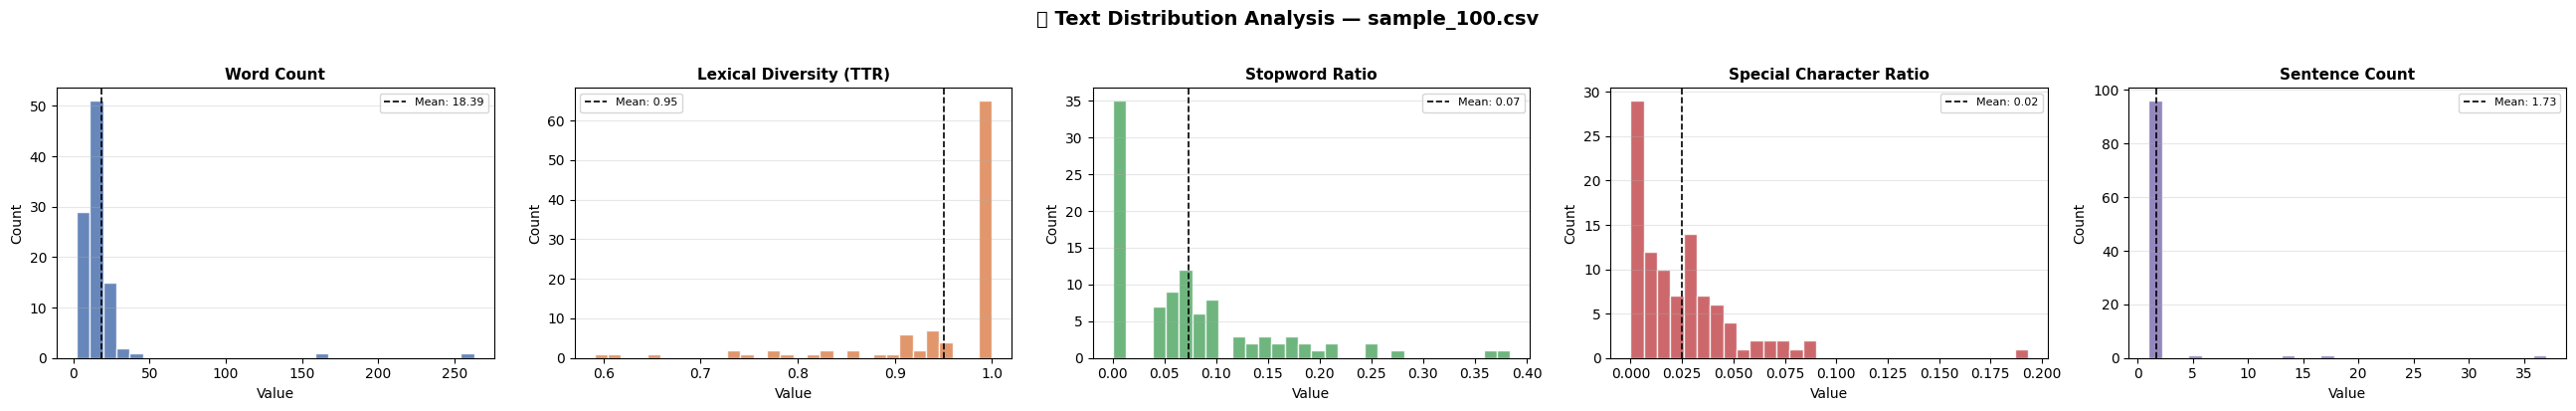

   ✅ Distribution plots rendered for 'sample_100.csv'.

🔤 Step 6 — Plotting top frequent words...


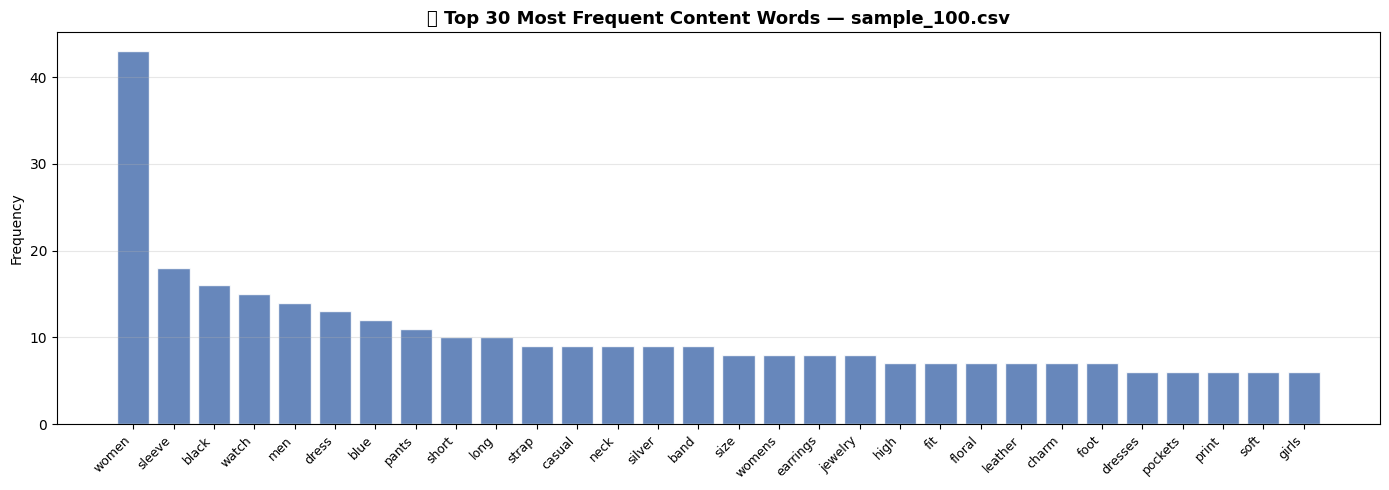

   ✅ Top words plot rendered for 'sample_100.csv'.

🧠 Step 7 — Running TF-IDF keyword importance analysis...

  📌 Top 20 TF-IDF Terms (corpus-level mean) — sample_100.csv:
       1. women                          score=0.06111
       2. black                          score=0.04390
       3. sleeve                         score=0.04230
       4. blue                           score=0.03799
       5. men                            score=0.03396
       6. dress                          score=0.03150
       7. short                          score=0.02919
       8. watch                          score=0.02848
       9. womens                         score=0.02748
      10. long                           score=0.02730
      11. casual                         score=0.02504
      12. size                           score=0.02488
      13. long sleeve                    score=0.02386
      14. silver                         score=0.02331
      15. shirt                          score=0.02264
   

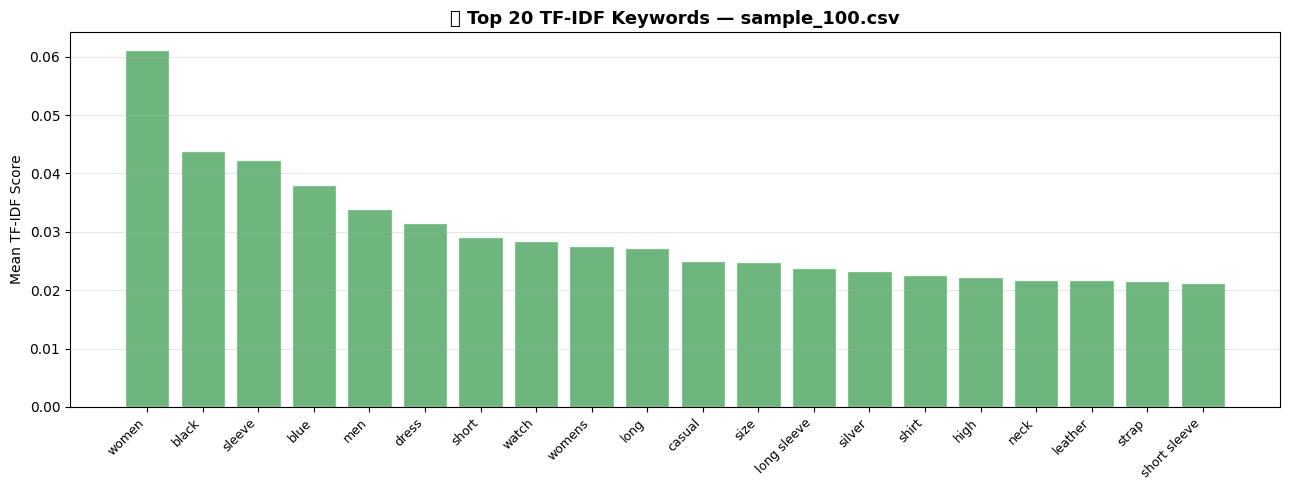

   ✅ TF-IDF analysis complete for 'sample_100.csv'.

🔎 Step 8 — Displaying random text samples...

  🔎  RANDOM TEXT SAMPLES — sample_100.csv  (n=10)

  [01] Cambond Watch Band 42mm Series 2 and Series 1 Durable Fully Magnetic Closure Clasp Mesh Loop Milanese Stainless Watch Band Strap Replacement for Watch Edition 42mm Black

  [02] BUSCBEAR Women's Plus Size Push Up Bras Underwire Comfort Lace Bra with Back Support Large Breasts Black

  [03] Ahappy-Gold Filled Sculpture Freemasonry Masonic Mason Pendant Necklace 19.68" 23.6" 27.55" 31.5" N282 Made of Quality Stainless Steel, Solid and Durable; Safe Material,It's a Healthy Choice.

  [04] Verdusa Women's V-Neck Short Sleeve Stripe Self Belted Dress Navy L

  [05] Bewish Silver Unisex Curved End Link Watch Band Single Fold Over Clasp Fits Round Watch Cases Tool (22mm)

  [06] QPANCY Galaxy Swimsuits for Girls 4t 5t Bathing Suits Swimwear Beach Clothes

  [07] Mini Lucky Horseshoe Diamond Pendant-Necklace in Sterling Silver

  [08] ZALA

In [12]:
run_pipeline(
    csv_files          = CSV_FILES,
    text_column        = TEXT_COLUMN,
    max_sample_display = MAX_SAMPLE_DISPLAY,
)